# 🐍 Python Level 3 - Advanced course
## Class 3 — Modules and Packages
### 📝 Practice Exercises — Solutions

**Python instructor - Fábio Neves**

---

<div style="display:inline-flex; align-items:center; gap:28px; background:#FFFFFF; color:#1D1D1B; padding:10px 14px; border-radius:8px; margin-bottom:8px;">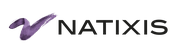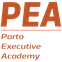</div>

---

---

One way to solve each exercise — not the only way. If yours prints the right thing and you can
explain it, yours is right too.

### 📁 The module notebooks

The three modules are in **this same folder**, already filled in:

| Notebook | Exercise |
|----------|----------|
| `shapes.ipynb` | B1 |
| `products.ipynb` | C1 |
| `shop_tools.ipynb` | D1 |

Open them to read the solutions to B1, C1 and D1 — a module's answer *is* the module. Run each
one before running this notebook, or simply run this notebook from the top: importing a
notebook runs it.

---

## ⚙️ Setup

In [ ]:
!pip install -q import-ipynb
import import_ipynb

print("Setup complete - let's build a module!")

---
## 🟢 Section A — Warm-up
### The standard library

> 🕐 Estimated time: 15 min

### Exercise A1 — `math`

In [ ]:
# A1
import math

print(math.sqrt(144))
print(round(math.pi, 4))
print(math.ceil(4.1), math.floor(4.9))

### Exercise A2 — `random`, made repeatable

The two lines match because `seed(7)` rewinds the randomness to the same starting place. The
values themselves depend on the Python version, so yours may differ — but the two lines must
agree.

In [ ]:
# A2
import random

cities = ["Porto", "Lisbon", "Faro", "Braga"]

random.seed(7)
print(random.randint(1, 100), random.choice(cities))

random.seed(7)
print(random.randint(1, 100), random.choice(cities))

### Exercise A3 — `statistics`

In [ ]:
# A3
import statistics

prices = [8.50, 4.20, 2.10, 1.15, 8.75, 4.20]

print("mean  :", round(statistics.mean(prices), 2))
print("median:", statistics.median(prices))
print("mode  :", statistics.mode(prices))
print("stdev :", round(statistics.stdev(prices), 2))

### Exercise A4 — `datetime`

In [ ]:
# A4
from datetime import date

launch = date(2026, 3, 14)

print(launch)
print(launch.strftime("%d/%m/%Y"))
print(launch.strftime("%d %B %Y"))
print(launch.year, launch.month, launch.day)

---
## 🟡 Section B — Core practice
### Writing and importing your own module

> 🕐 Estimated time: 25 min

### Exercise B1 — Write your first module

The answer is **`shapes.ipynb`** in this folder. It holds nothing but a docstring, a value and
two functions:

```python
"""Simple shape measurements."""

UNIT = "cm"


def area(width, height):
    """Return the area of a rectangle."""
    return width * height


def perimeter(width, height):
    """Return the perimeter of a rectangle."""
    return 2 * (width + height)
```

In [ ]:
# B1
import shapes

print("shapes imported")

### Exercise B2 — Import and use it

In [ ]:
# B2
print(shapes.area(3, 4))
print(shapes.perimeter(3, 4))
print(shapes.area(10, 5))

### Exercise B3 — The three import styles

In [ ]:
# B3
import shapes
print(shapes.area(6, 7))

from shapes import area
print(area(6, 7))

import shapes as sh
print(sh.area(6, 7))

### Exercise B4 — The value in the module

In [ ]:
# B4
from shapes import UNIT, area

print(UNIT)
print(f"A 3x4 rectangle has an area of {area(3, 4)} square {UNIT}")

---
## 🟠 Section C — Applied
### A module that does real work

> 🕐 Estimated time: 25 min

### Exercise C1 — A module with a class in it

The answer is **`products.ipynb`** in this folder. The three things worth noticing:

- it does `import statistics` **at its own top**, so whoever imports `products` does not have to
- `describe()` calls `format_eur()` directly — same file, no import needed
- `summarise()` uses a list comprehension over `item.value()`, from Level 2 Class 2

In [ ]:
# C1
import products

print("products imported")

### Exercise C2 — Use the class

In [ ]:
# C2
from products import Product, format_eur

coffee = Product("Coffee", 8.50, 12)
tea = Product("Tea", 4.20, 30)

print(coffee.describe())
print(tea.describe())
print(format_eur(coffee.value()))
print(format_eur(tea.value()))

### Exercise C3 — Use the summary

In [ ]:
# C3
items = [
    coffee,
    tea,
    Product("Sugar", 2.10, 8),
    Product("Milk", 1.15, 40),
]

summary = products.summarise(items)
print(summary)
print(
    f"{summary['products']} products worth {format_eur(summary['value'])}, "
    f"average price {format_eur(summary['average_price'])}"
)

---
## 🔴 Section D — Challenge
### A module built on another module

> 🕐 Estimated time: 25 min

### Exercise D1 — A module that imports a module

The answer is **`shop_tools.ipynb`** in this folder. What makes it the challenge:

- it starts with `import products` — a module using a module
- `stock_summary()` **asks `products.summarise()` first**, then adds only the two things
  `products` cannot know: the VAT total and the low-stock count
- every rule the shop has — the VAT rate, the stock limit, the shape of a line — lives here and
  nowhere else

In [ ]:
# D1
import shop_tools

print("shop_tools imported")

### Exercise D2 — A cell with no rules in it

Read the cell below and notice what is *missing*: no `23`, no `10`, no `:,.2f`, no
multiplication. Only data, a loop, and calls into the modules. That is the whole point of the
exercise — every rule moved into `shop_tools`, so changing the VAT rate means editing one line
in one place.

In [ ]:
# D2
items = [
    Product("Coffee", 8.50, 12),
    Product("Tea", 4.20, 30),
    Product("Sugar", 2.10, 8),
    Product("Milk", 1.15, 40),
    Product("Olive oil", 8.75, 4),
]

print("STOCK REPORT")
print("-" * 40)
for item in items:
    print(shop_tools.report_line(item))
print("-" * 40)

summary = shop_tools.stock_summary(items)
print(f"{'Products':<14}: {summary['products']}")
print(f"{'Value':<14}: {format_eur(summary['value'])}")
print(f"{'With VAT':<14}: {format_eur(summary['with_vat'])}")
print(f"{'Average price':<14}: {format_eur(summary['average_price'])}")
print(f"{'Low on stock':<14}: {summary['low']}")

---

### 🎉 Well done!

| | Concept | Exercises |
|-|---------|----------|
| ✅ | `math` | A1 |
| ✅ | `random` and `seed` | A2 |
| ✅ | `statistics` | A3, C1 |
| ✅ | `datetime` | A4 |
| ✅ | A module written as a notebook | B1, C1, D1 |
| ✅ | `import_ipynb` | setup |
| ✅ | `import x` | B1, B2, C1, D1 |
| ✅ | `from x import y` | B3, C2 |
| ✅ | `import x as y` | B3 |
| ✅ | A value in a module | B4, D1 |
| ✅ | A class in a module | C1, C2 |
| ✅ | One module importing another | D1 |
| ✅ | A cell that only calls the modules | D2 |

> 💡 **The habit worth taking:** when you find yourself pasting the same function into a third
> notebook, that is the moment to make a module. Not before — a helper used once belongs where
> it is used.